In [97]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from dataclasses import dataclass

# Mamba2 kontrolü
try:
    from mamba_ssm import Mamba2
    print("Mamba2 kütüphanesi hazır.")
except ImportError:
    print("UYARI: 'mamba_ssm' bulunamadı. Lütfen kurulu olduğundan emin olun.")

# --- 1. Hiperparametre Konfigürasyonu ---
@dataclass
class TrainingConfig:
    # Veri Ayarları
    window_size: int = 128     # Modele girecek zaman penceresi uzunluğu (Eski adıyla seq_len)
    batch_size: int = 64      # Batch size

    # Model Mimarisi (Mamba2)
    input_dim: int = 17       # Metadata (2) ve Target (1) çıkınca kalan özellik sayısı
    d_model: int = 128         # Model boyutu
    n_layers: int = 2         # Katman sayısı
    d_state: int = 64         # SSM state boyutu
    d_head: int = 32          # Head boyutu
    expand: int = 2           # Expansion factor
    dropout: float =0.2

    # Eğitim ve Donanım Ayarları
    learning_rate: float = 5e-4
    num_epochs: int = 100
    seed: int = 42
    # L4 GPU için bfloat16 seçimi
    dtype: torch.dtype = torch.bfloat16
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

# --- 2. Sadeleştirilmiş Seed Fonksiyonu ---
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    print(f"Seed {seed} olarak ayarlandı. Cihaz: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

# Yapılandırmayı çalıştır
config = TrainingConfig()
set_seed(config.seed)
print(f"Veri tipi: {config.dtype}")

Mamba2 kütüphanesi hazır.
Seed 42 olarak ayarlandı. Cihaz: NVIDIA L4
Veri tipi: torch.bfloat16


In [98]:
class CMAPSSDataset(Dataset):
    def __init__(self, data, config, mode='train'):
        """
        data: Pandas DataFrame (işlenmiş veri)
        config: Hiperparametre sınıfı
        mode: 'train' veya 'val' (Sadece loglama için)
        """
        self.window_size = config.window_size
        self.input_columns = [c for c in data.columns if c not in ['unit_nr', 'time_cycles', 'RUL']]
        self.target_column = 'RUL'

        self.samples = []
        self.targets = []

        # Veriyi unit_nr'ye göre grupla
        grouped = data.groupby('unit_nr')

        print(f"[{mode.upper()}] Veri hazırlanıyor... Toplam Unit Sayısı: {len(grouped)}")

        for unit_id, group in grouped:
            # Metadata sütunlarını çıkar, sadece sensör verilerini al
            # float32'ye çeviriyoruz (Model içinde bfloat16'ya cast edilecek)
            features = group[self.input_columns].values.astype(np.float32)
            ruls = group[self.target_column].values.astype(np.float32)

            num_time_steps = len(features)

            # Eğer motorun ömrü window_size'dan kısaysa bu motoru atla (veya padding yapılabilir)
            if num_time_steps < self.window_size:
                continue

            # Sliding Window (Kayan Pencere) Oluşturma
            # Örnek: T=150, W=128 ise -> 150 - 128 + 1 = 23 örnek çıkar
            for i in range(num_time_steps - self.window_size + 1):
                # X: i'den i+window_size'a kadar olan sensör verileri
                window_x = features[i : i + self.window_size]

                # y: Pencerenin sonundaki (i + window_size - 1) RUL değeri
                # Hedef, pencerenin son anındaki RUL'dur.
                target_y = ruls[i + self.window_size - 1]

                self.samples.append(window_x)
                self.targets.append(target_y)

        # Listeleri tensöre çevir
        self.samples = torch.tensor(np.array(self.samples))
        self.targets = torch.tensor(np.array(self.targets)).unsqueeze(1) # (N, 1) formatı için

        print(f"[{mode.upper()}] Tamamlandı. Oluşturulan pencere (örnek) sayısı: {len(self.samples)}")
        print(f"[{mode.upper()}] Tensor Shape: {self.samples.shape}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx], self.targets[idx]

# --- Veriyi Yükleme ve Hazırlama ---

# Dosya yollarını tanımla (Colab veya yerel dizine göre güncelleyebilirsin)
train_path = 'train_FD004_processed.csv'
test_path = 'test_FD004_processed.csv'

# Veriyi oku (Dosyaların bulunduğu dizinde çalıştığından emin ol)
if os.path.exists(train_path):
    df_all = pd.read_csv(train_path)
    print("Veri seti dosyadan okundu.")
else:
    # Dosya yoksa hata vermemesi için dummy veri oluşturalım (Test amaçlı)
    print(f"UYARI: {train_path} bulunamadı! Test için rastgele veri üretiliyor...")
    cols = ['unit_nr', 'time_cycles'] + [f'setting_{i}' for i in range(1,4)] + [f's_{i}' for i in range(1,22) if i not in [1,5,6,10,16,18,19]] + ['RUL']
    # 249 unit için rastgele uzunlukta veriler
    data_list = []
    for u in range(1, 250):
        length = np.random.randint(130, 300) # Window size'dan büyük olmalı
        temp_df = pd.DataFrame(np.random.rand(length, len(cols)), columns=cols)
        temp_df['unit_nr'] = u
        temp_df['time_cycles'] = np.arange(1, length+1)
        data_list.append(temp_df)
    df_all = pd.concat(data_list).reset_index(drop=True)

# --- Unit Bazlı Split (Ayırma) ---
# Toplam 249 unit var. 38 tanesi Validation, kalanı Train.
all_units = df_all['unit_nr'].unique()
val_unit_count = 38
train_unit_count = len(all_units) - val_unit_count

# Son 38 motoru validation olarak ayırıyoruz (veya rastgele de seçebilirdik ama genelde sonuncular alınır)
train_units = all_units[:train_unit_count]
val_units = all_units[train_unit_count:]

print(f"\nToplam Unit: {len(all_units)}")
print(f"Train Unitleri ({len(train_units)} adet): {train_units[:5]} ... {train_units[-5:]}")
print(f"Val Unitleri ({len(val_units)} adet): {val_units}")

# DataFrame'i bölüyoruz
train_df = df_all[df_all['unit_nr'].isin(train_units)]
val_df = df_all[df_all['unit_nr'].isin(val_units)]

# Datasetleri oluştur
train_dataset = CMAPSSDataset(train_df, config, mode='train')
val_dataset = CMAPSSDataset(val_df, config, mode='val')

# DataLoaderları oluştur
# Train setini karıştırıyoruz (Shuffle=True), Val setini karıştırmıyoruz.
# num_workers=2 veya 4 yapabilirsin, şimdilik 0 (ana süreç) güvenli mod.
train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True # GPU transferini hızlandırır
)

val_loader = DataLoader(
    val_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# Kontrol
X_batch, y_batch = next(iter(train_loader))
print(f"\nBatch Kontrolü:")
print(f"X (Input) Shape: {X_batch.shape} -> (Batch, Window, Features)") # Beklenen: (64, 128, 17)
print(f"y (Target) Shape: {y_batch.shape}") # Beklenen: (64, 1)

Veri seti dosyadan okundu.

Toplam Unit: 249
Train Unitleri (211 adet): [1 2 3 4 5] ... [207 208 209 210 211]
Val Unitleri (38 adet): [212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229
 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247
 248 249]
[TRAIN] Veri hazırlanıyor... Toplam Unit Sayısı: 211
[TRAIN] Tamamlandı. Oluşturulan pencere (örnek) sayısı: 25302
[TRAIN] Tensor Shape: torch.Size([25302, 128, 17])
[VAL] Veri hazırlanıyor... Toplam Unit Sayısı: 38
[VAL] Tamamlandı. Oluşturulan pencere (örnek) sayısı: 4324
[VAL] Tensor Shape: torch.Size([4324, 128, 17])

Batch Kontrolü:
X (Input) Shape: torch.Size([64, 128, 17]) -> (Batch, Window, Features)
y (Target) Shape: torch.Size([64, 1])


In [99]:
# --- 3. Model Mimarisi (FİNAL VERSİYON: Sigmoid + Dropout) ---

import torch
import torch.nn as nn
from mamba_ssm import Mamba2


class RMSNorm(nn.Module):
    def __init__(self, d_model: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d_model))

    def forward(self, x):
        output = x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        return output * self.weight

class MambaBlock(nn.Module):
    """
    Norm -> Mamba2 -> Dropout -> Residual Connection
    """
    def __init__(self, config):
        super().__init__()
        self.norm = RMSNorm(config.d_model)

        self.mamba = Mamba2(
            d_model=config.d_model,
            d_state=config.d_state,
            d_conv=4,
            expand=config.expand,
            headdim=config.d_head
        )

        # --- DROPOUT (Block İçi) ---
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        residual = x

        x = self.norm(x)
        x = self.mamba(x)

        # Mamba çıkışını rastgele kapat (Regularization)
        x = self.dropout(x)

        x = residual + x
        return x

class MambaRULModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        # Input Projection
        self.input_proj = nn.Linear(config.input_dim, config.d_model)

        # --- INPUT DROPOUT ---
        self.input_dropout = nn.Dropout(config.dropout)

        # Backbone
        self.layers = nn.ModuleList([
            MambaBlock(config) for _ in range(config.n_layers)
        ])

        # Final Normalization
        self.norm_f = RMSNorm(config.d_model)

        # Output Head
        self.head = nn.Linear(config.d_model, 1)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)

    def forward(self, x):
        # 1. Projection
        x = self.input_proj(x)

        # 2. Input Dropout
        x = self.input_dropout(x)

        # 3. Mamba Blocks
        for layer in self.layers:
            x = layer(x)

        # 4. Final Norm
        x = self.norm_f(x)

        # 5. Last Token Pooling
        x_last = x[:, -1, :]

        # 6. Head
        out = self.head(x_last)

        # 7. Sigmoid (0-1 arası çıktı)
        return torch.sigmoid(out)

# Modeli yeniden başlat
model = MambaRULModel(config).to(config.device)
if config.dtype == torch.bfloat16:
    model = model.to(dtype=torch.bfloat16)

print(f"Model Tamamlandı: Dropout ({config.dropout}) ve Sigmoid aktif.")

# Hızlı Test
dummy_input = torch.randn(2, config.window_size, config.input_dim).to(config.device, dtype=config.dtype)
with torch.no_grad():
    output = model(dummy_input)
print(f"Çıktı Shape: {output.shape} (Değer 0-1 arası: {output[0].item():.4f})")

Model Tamamlandı: Dropout (0.2) ve Sigmoid aktif.
Çıktı Shape: torch.Size([2, 1]) (Değer 0-1 arası: 0.3066)


In [100]:
import torch.optim as optim
import math

# --- 4. Eğitim Döngüsü (GÜNCELLENMİŞ: Her İkisi de Real Unit) ---

best_model_path = "best_mamba_rul_model.pth"
optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=0.5)
criterion = nn.MSELoss()

MAX_RUL = 125.0

patience = 5
patience_counter = 0
lr_drop_counter = 0
max_lr_drops = 2
best_val_rmse = float('inf')

print(f"Eğitim Başlıyor... Tüm metrikler GERÇEK (Real) Cycle cinsinden raporlanacak.")
print("-" * 85)

for epoch in range(config.num_epochs):
    # --- TRAINING ---
    model.train()
    train_loss_sum = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(config.device, dtype=config.dtype)
        y_batch = y_batch.to(config.device, dtype=config.dtype)

        # Hedef ölçekleme (Eğitim stabilitesi için gerekli)
        y_scaled = y_batch / MAX_RUL
        y_scaled = torch.clamp(y_scaled, 0.0, 1.0)

        optimizer.zero_grad()
        preds = model(X_batch)

        loss = criterion(preds, y_scaled)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss_sum += loss.item()

    # Train RMSE (Real) Hesaplama:
    # Scaled MSE'nin karekökünü alıp 125 ile çarpıyoruz.
    avg_train_mse_scaled = train_loss_sum / len(train_loader)
    avg_train_rmse_real = math.sqrt(avg_train_mse_scaled) * MAX_RUL

    # --- VALIDATION ---
    model.eval()
    val_mse_sum = 0

    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val = X_val.to(config.device, dtype=config.dtype)
            y_val = y_val.to(config.device, dtype=config.dtype)

            preds_scaled = model(X_val)

            # Ters dönüşüm yapıp hatayı gerçek birimde hesaplıyoruz
            preds_real = preds_scaled * MAX_RUL
            loss_real = nn.MSELoss()(preds_real, y_val)
            val_mse_sum += loss_real.item()

    avg_val_rmse_real = math.sqrt(val_mse_sum / len(val_loader))

    # --- LOG & SCHEDULER ---
    current_lr = optimizer.param_groups[0]['lr']

    # Artık her ikisi de aynı birimde
    print(f"Epoch {epoch+1:03d} | Train RMSE: {avg_train_rmse_real:.4f} | Val RMSE: {avg_val_rmse_real:.4f} | LR: {current_lr:.2e}")

    if avg_val_rmse_real < best_val_rmse:
        best_val_rmse = avg_val_rmse_real
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  -> {patience} epoch iyileşme yok. En iyi Val RMSE: {best_val_rmse:.4f}")
            lr_drop_counter += 1

            if lr_drop_counter >= max_lr_drops:
                print("  STOP: Maksimum LR düşüşüne ulaşıldı.")
                break

            print(f"  Action: Model resetleniyor ve LR bölünüyor...")
            model.load_state_dict(torch.load(best_model_path))
            new_lr = current_lr / 5.0
            for param_group in optimizer.param_groups:
                param_group['lr'] = new_lr
            patience_counter = 0

print(f"Eğitim Bitti. Best Val RMSE: {best_val_rmse:.4f}")
model.load_state_dict(torch.load(best_model_path))

Eğitim Başlıyor... Tüm metrikler GERÇEK (Real) Cycle cinsinden raporlanacak.
-------------------------------------------------------------------------------------
Epoch 001 | Train RMSE: 39.7265 | Val RMSE: 31.4300 | LR: 5.00e-04
Epoch 002 | Train RMSE: 30.5264 | Val RMSE: 26.7188 | LR: 5.00e-04
Epoch 003 | Train RMSE: 28.7853 | Val RMSE: 29.9979 | LR: 5.00e-04
Epoch 004 | Train RMSE: 28.1794 | Val RMSE: 24.1166 | LR: 5.00e-04
Epoch 005 | Train RMSE: 26.3121 | Val RMSE: 23.8634 | LR: 5.00e-04
Epoch 006 | Train RMSE: 25.4877 | Val RMSE: 22.9975 | LR: 5.00e-04
Epoch 007 | Train RMSE: 23.4878 | Val RMSE: 20.4392 | LR: 5.00e-04
Epoch 008 | Train RMSE: 21.8938 | Val RMSE: 21.2698 | LR: 5.00e-04
Epoch 009 | Train RMSE: 20.7404 | Val RMSE: 25.9830 | LR: 5.00e-04
Epoch 010 | Train RMSE: 19.5964 | Val RMSE: 20.4068 | LR: 5.00e-04
Epoch 011 | Train RMSE: 18.1110 | Val RMSE: 18.6278 | LR: 5.00e-04
Epoch 012 | Train RMSE: 17.5720 | Val RMSE: 17.9670 | LR: 5.00e-04
Epoch 013 | Train RMSE: 16.7551 |

<All keys matched successfully>

Test verisi yükleniyor: test_FD004_processed.csv
Toplam 248 motor için tahmin üretiliyor...

PERFORMANS SONUÇLARI (Test FD004 - Processed)
MSE (Mean Squared Error)       : 345.3551
RMSE (Root Mean Squared Error) : 18.5837
MAE (Mean Absolute Error)      : 12.9980
MAPE (Mean Abs Percent Error)  : 24.89%
CMAPSS Score                   : 2898.0642
----------------------------------------

Örnek Sonuçlar (İlk 10 Unit):
 Unit  True_RUL  Pred_RUL  Error (E)  Abs_Error  APE (%)
    1        22      8.42     -13.58      13.58    61.71
    2        39     48.10       9.10       9.10    23.32
    3       107    107.42       0.42       0.42     0.39
    4        75     64.45     -10.55      10.55    14.06
    5       125     94.73     -30.27      30.27    24.22
    6        78    101.07      23.07      23.07    29.58
    7        94    118.65      24.65      24.65    26.23
    8        14      8.42      -5.58       5.58    39.84
    9        99     62.01     -36.99      36.99    37.36
   10       

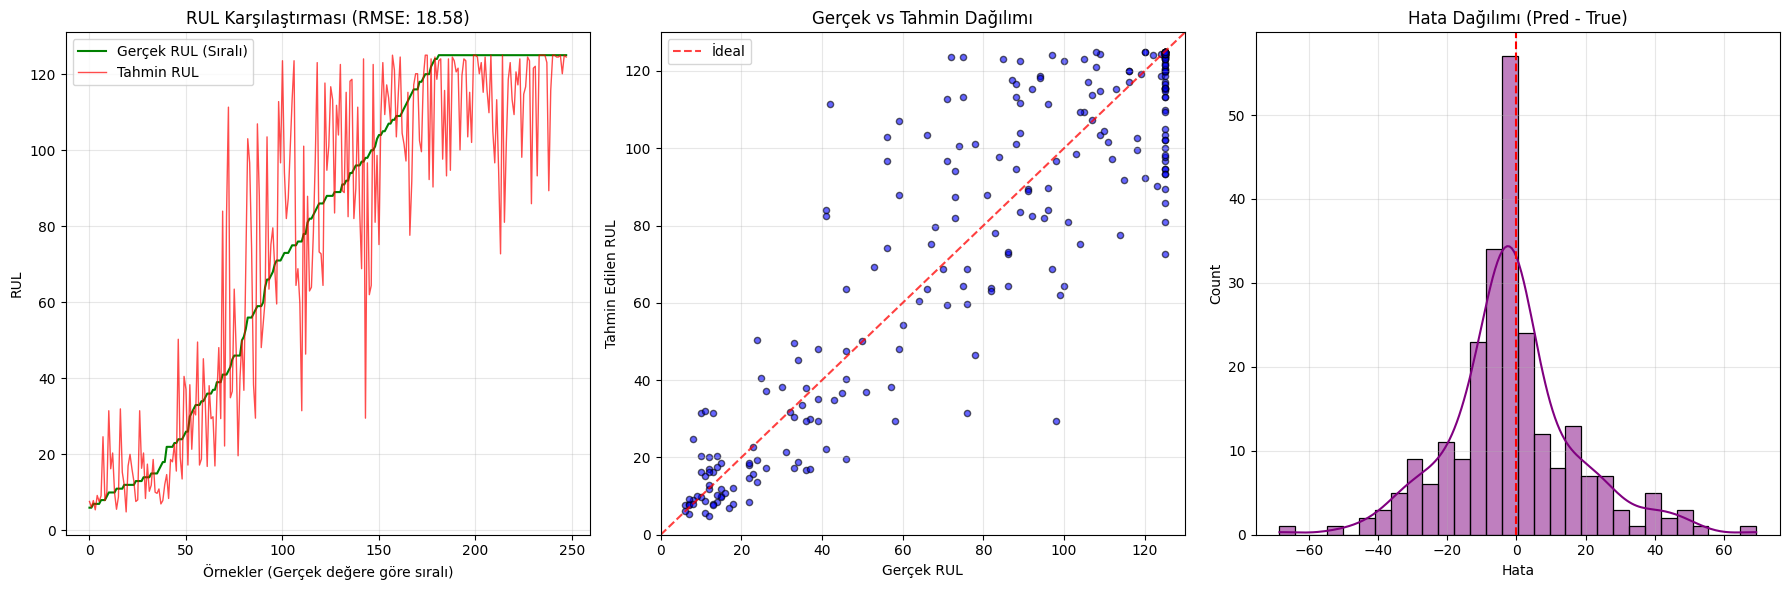

In [101]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# --- 5. Test, Padding ve Görselleştirme (GÜNCEL: TXT dosyasız) ---

def evaluate_model(model, config, test_df_path):
    # Dosya yolu kontrolü
    if not os.path.exists(test_df_path):
        print(f"UYARI: Test dosyası bulunamadı: {test_df_path}")
        return

    print(f"Test verisi yükleniyor: {test_df_path}")
    test_df = pd.read_csv(test_df_path)

    # Model hazırlığı
    model.eval()

    predictions = []
    true_ruls = []

    # Test verisindeki input sütunları (metadata ve target hariç)
    # 'RUL' sütunu artık input değil, hedef olarak kullanılacak
    input_columns = [c for c in test_df.columns if c not in ['unit_nr', 'time_cycles', 'RUL']]

    # Unitlere göre grupla
    grouped = test_df.groupby('unit_nr')

    print(f"Toplam {len(grouped)} motor için tahmin üretiliyor...")

    for unit_nr, group in grouped:
        # 1. GERÇEK DEĞERİ ALMA:
        # Her unit'in verisindeki EN SON satırın RUL değeri, o unit'in test sonucudur.
        current_true_rul = group['RUL'].iloc[-1]
        true_ruls.append(current_true_rul)

        # 2. GİRDİ VERİSİNİ HAZIRLAMA:
        seq = group[input_columns].values.astype(np.float32)

        # --- PADDING MANTIĞI ---
        seq_len = seq.shape[0]

        if seq_len < config.window_size:
            # Eksik parça sayısı
            diff = config.window_size - seq_len
            # İlk satırı al
            first_row = seq[0:1, :]
            # İlk satırı çoğalt ve başa ekle
            padding = np.repeat(first_row, diff, axis=0)
            seq_padded = np.vstack([padding, seq])
        else:
            # 128 veya daha fazlaysa son 128'i al
            seq_padded = seq[-config.window_size:, :]

        # Tensöre çevir: (1, 128, 17)
        x_tensor = torch.tensor(seq_padded).unsqueeze(0)
        x_tensor = x_tensor.to(config.device, dtype=config.dtype)

        with torch.no_grad():
            # Model 0-1 arası çıktı verir (Sigmoid)
            out = model(x_tensor)

            # Gerçek skalaya (125) çevir
            # NOT: Senin veri setinde RUL zaten clip'lendiği için 125 ile çarpmak doğrudur.
            pred_rul = out.item() * 125.0
            predictions.append(pred_rul)

    # Listeleri Numpy dizisine çevir
    y_pred = np.array(predictions)
    y_true = np.array(true_ruls)

    # --- METRİK HESAPLAMALARI ---
    E = y_pred - y_true          # Error
    AE = np.abs(E)               # Absolute Error
    SE = E ** 2                  # Squared Error

    # Sıfıra bölme koruması
    PE = (E / (y_true + 1e-6)) * 100
    APE = np.abs(PE)             # Absolute Percent Error

    # Aggregated Metrikler
    MSE = np.mean(SE)
    RMSE = np.sqrt(MSE)
    MAE = np.mean(AE)
    MAPE = np.mean(APE)

    # CMAPSS Score
    s_score = np.sum(np.where(E < 0, np.exp(-E/13)-1, np.exp(E/10)-1))

    print("\n" + "="*40)
    print(f"PERFORMANS SONUÇLARI (Test FD004 - Processed)")
    print("="*40)
    print(f"MSE (Mean Squared Error)       : {MSE:.4f}")
    print(f"RMSE (Root Mean Squared Error) : {RMSE:.4f}")
    print(f"MAE (Mean Absolute Error)      : {MAE:.4f}")
    print(f"MAPE (Mean Abs Percent Error)  : {MAPE:.2f}%")
    print(f"CMAPSS Score                   : {s_score:.4f}")
    print("-"*40)

    # --- DETAYLI TABLO (İlk 10 Örnek) ---
    results_df = pd.DataFrame({
        'Unit': grouped.groups.keys(), # Unit numaralarını koru
        'True_RUL': y_true,
        'Pred_RUL': np.round(y_pred, 2),
        'Error (E)': np.round(E, 2),
        'Abs_Error': np.round(AE, 2),
        'APE (%)': np.round(APE, 2)
    })

    print("\nÖrnek Sonuçlar (İlk 10 Unit):")
    print(results_df.head(10).to_string(index=False))

    # --- GÖRSELLEŞTİRME ---
    plt.figure(figsize=(18, 6))

    # Grafik 1: Gerçek vs Tahmin
    plt.subplot(1, 3, 1)
    # Veriyi sıralayarak çizdirmek trendi görmeyi kolaylaştırır
    sort_idx = np.argsort(y_true)
    plt.plot(y_true[sort_idx], label='Gerçek RUL (Sıralı)', color='green', linewidth=1.5)
    plt.plot(y_pred[sort_idx], label='Tahmin RUL', color='red', alpha=0.7, linewidth=1)
    plt.title(f'RUL Karşılaştırması (RMSE: {RMSE:.2f})')
    plt.xlabel('Örnekler (Gerçek değere göre sıralı)')
    plt.ylabel('RUL')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Grafik 2: Scatter Plot
    plt.subplot(1, 3, 2)
    plt.scatter(y_true, y_pred, alpha=0.6, c='blue', edgecolors='k', s=20)
    lims = [0, 140] # 125 + marj
    plt.plot(lims, lims, 'r--', alpha=0.75, label='İdeal')
    plt.title('Gerçek vs Tahmin Dağılımı')
    plt.xlabel('Gerçek RUL')
    plt.ylabel('Tahmin Edilen RUL')
    plt.xlim(0, 130)
    plt.ylim(0, 130)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Grafik 3: Hata Dağılımı
    plt.subplot(1, 3, 3)
    sns.histplot(E, kde=True, color='purple', bins=30)
    plt.axvline(0, color='red', linestyle='--')
    plt.title('Hata Dağılımı (Pred - True)')
    plt.xlabel('Hata')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- Fonksiyonu Çalıştır ---
evaluate_model(
    model,
    config,
    test_df_path='test_FD004_processed.csv' # Sadece CSV yolu yeterli
)